In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
data = pd.read_csv("aapl.csv")


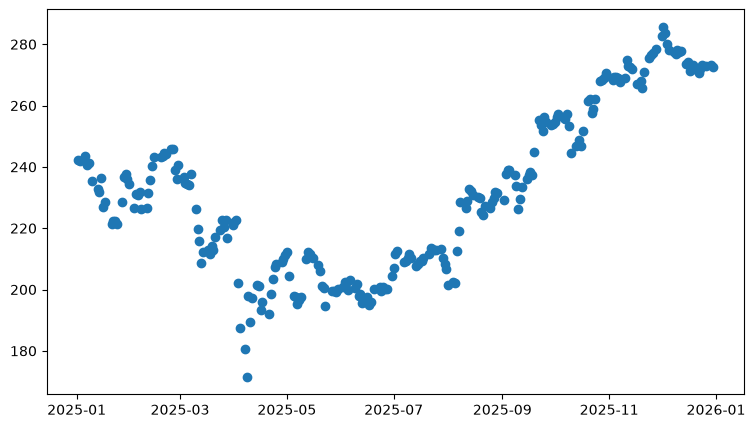

In [ ]:
data = data[data['Year'].between(2025, 2026)].copy()
data['Date'] = pd.to_datetime(data['Date'])
data['Close'] = pd.to_numeric(
    data['Close'].astype(str).str.replace(',', ''), errors='coerce'
)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(data['Date'], data['Close'], color='#1f77b4',
         linestyle='', marker='o', label='APPLE STOCK')
plt.show()

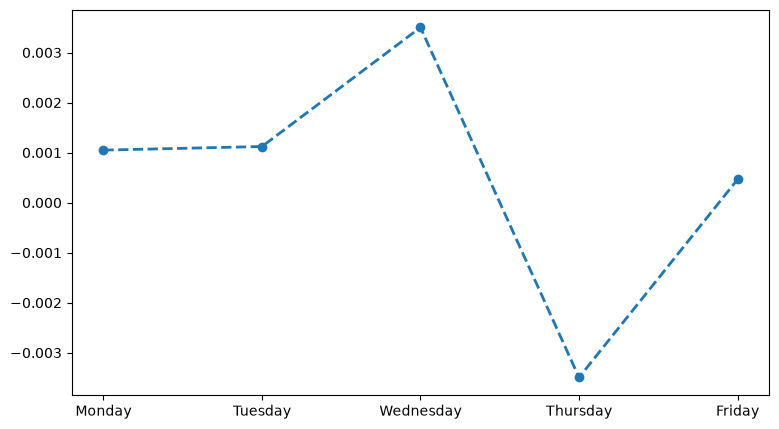

In [ ]:
Monday = data[data["Weekday"] == "Monday"]["Return"].mean()
Tuesday = data[data["Weekday"] == "Tuesday"]["Return"].mean()
Wednesday = data[data["Weekday"] == "Wednesday"]["Return"].mean()
Thursday = data[data["Weekday"] == "Thursday"]["Return"].mean()
Friday = data[data["Weekday"] == "Friday"]["Return"].mean()
Order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(Order, Returns, color='#1f77b4',
         linestyle='--', marker='o', label='APPLE STOCK', linewidth = 2.0)


249


<function matplotlib.pyplot.show(close=None, block=None)>

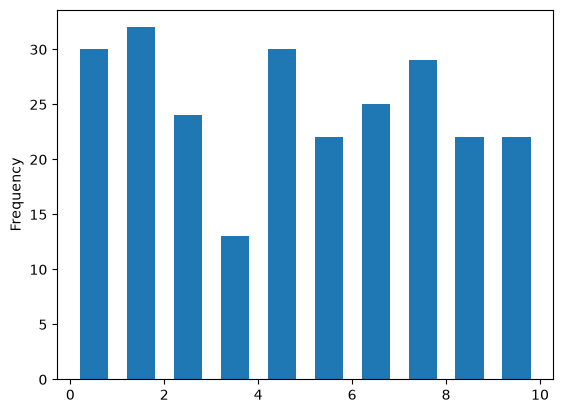

In [ ]:
close = pd.to_numeric(data["Close"])
ld = close * 100 % 10 
ld.plot(kind='hist', bins = 10,rwidth = 0.6)
print(len(ld))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

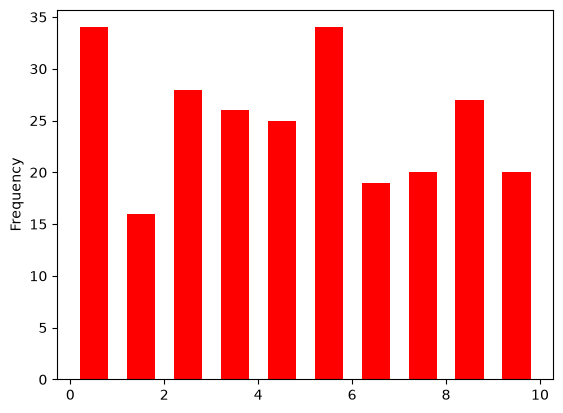

In [ ]:
open = pd.to_numeric(data["Open"])
ld = open * 100 % 10 
ld.plot(kind='hist', bins = 10,rwidth = 0.6, color = "red")
plt.show

In [ ]:
from read_and_save_stock_data import get_stock
import matplotlib.pyplot as plt
import pandas as pd

# Pull data using the existing helper script
AAPL = get_stock("AAPL", "2021-01-01", "2025-12-31", 14, 50)
SPY = get_stock("SPY", "2021-01-01", "2025-12-31", 14, 50)

if AAPL is not None and SPY is not None:
    # --- ADD THESE TWO LINES TO DROP THE SECOND HEADER ROW ---
    AAPL = AAPL[AAPL["Date"].notna() & (AAPL["Date"] != "")]
    SPY = SPY[SPY["Date"].notna() & (SPY["Date"] != "")]

    # Your existing code continues here:
    merged = (
        AAPL[["Date", "Close", "Return"]]
        .merge(SPY[["Date", "Close", "Return"]], on="Date", suffixes=("_AAPL", "_SPY"))
        .dropna()
    )
    
    # Convert types to numeric so matplotlib can map them
    merged["Date"] = pd.to_datetime(merged["Date"])
    merged["Close_AAPL"] = pd.to_numeric(merged["Close_AAPL"])
    merged["Close_SPY"] = pd.to_numeric(merged["Close_SPY"])
    merged["Return_AAPL"] = pd.to_numeric(merged["Return_AAPL"])
    merged["Return_SPY"] = pd.to_numeric(merged["Return_SPY"])

    # --- Matplotlib will now plot everything safely ---
    plt.figure(figsize=(10, 4))
    plt.plot(merged["Date"], merged["Close_AAPL"], label="AAPL")
    plt.plot(merged["Date"], merged["Close_SPY"], label="SPY")
    plt.title("AAPL vs SPY")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.scatter(merged["Return_SPY"], merged["Return_AAPL"], alpha=0.6)
    plt.title("AAPL Return vs SPY Return")
    plt.xlabel("SPY Return")
    plt.ylabel("AAPL Return")
    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\Jeremy\AppData\Local\Temp\ipykernel_50880\2382368261.py:17: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  .merge(SPY[["Date", "Close", "Return"]], on="Date", suffixes=("_AAPL", "_SPY"))


KeyError: 'Close_AAPL'